In [1]:
# Clone your GitHub repo
!git clone https://github.com/Kashshaf-Labib/synth-dataset-pipeline.git
%cd synth-dataset-pipeline

Cloning into 'synth-dataset-pipeline'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 51 (delta 26), reused 40 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 423.56 KiB | 10.08 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/kaggle/working/synth-dataset-pipeline


In [2]:
# Install dependencies
!pip install -q langchain langchain-google-genai langchain-google-vertexai \
    langchain-openai openai google-generativeai google-cloud-aiplatform \
    google-genai pandas python-dotenv Pillow pydantic tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.5/733.5 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.4/344.4 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 35.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# Authenticate using your service account key or user credentials
# Option A: If you saved your GCP service account key as a Kaggle Secret:
import os, json
from google.oauth2 import service_account
from google.auth.transport.requests import Request

# Paste your service account JSON as a Kaggle Secret named "GCP_SA_KEY"
from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
sa_key = json.loads(secrets.get_secret("GCP_SA_KEY"))

# Write to a temp file and set env var
with open("/tmp/sa_key.json", "w") as f:
    json.dump(sa_key, f)
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/tmp/sa_key.json"
print("✅ Service account credentials set")


✅ Service account credentials set


In [ ]:
import os
from kaggle_secrets import UserSecretsClient

# Load API key from Kaggle Secrets (never hardcode!)
secrets = UserSecretsClient()
google_api_key = secrets.get_secret("GOOGLE_API_KEY")

env_content = f"""
# === API Keys ===
OPENAI_API_KEY=
GOOGLE_API_KEY={google_api_key}

# === Vertex AI Config ===
GCP_PROJECT_ID=spai-img-gen
GCP_LOCATION=global
GCP_IMAGE_LOCATION=global

# === Pipeline Config ===
IMAGE_GENERATOR=gemini
CHAT_MODEL=gemini-3-flash-preview
GEMINI_IMAGE_MODEL=gemini-3-pro-image-preview
DALLE_MODEL=dall-e-3
DALLE_IMAGE_SIZE=1024x1024
DALLE_IMAGE_QUALITY=standard
""".strip()

with open(".env", "w") as f:
    f.write(env_content)
print("✅ .env created (API key loaded from Kaggle Secrets)")

✅ .env created


In [5]:
import os

images_dir = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized"
sample_files = os.listdir(images_dir)[:5]
print(f"✅ Images directory has {len(os.listdir(images_dir))} files")
print(f"   Sample: {sample_files}")

✅ Images directory has 7470 files
   Sample: ['349_IM-1697-2001.dcm.png', '607_IM-2196-1001.dcm.png', '2832_IM-1249-2001.dcm.png', '699_IM-2263-2001.dcm.png', '1931_IM-0602-2001.dcm.png']


In [6]:
from pipeline.report_parser import load_projections, load_reports

proj = load_projections("indiana_projections.csv")
print(f"✅ {len(proj)} uids with projection data")
print(f"   uid=1: {[(i.filename, i.projection) for i in proj[1]]}")

# Check images actually exist on disk
uid1_paths = [f"{images_dir}/{i.filename}" for i in proj[1]]
for p in uid1_paths:
    print(f"   {'✅' if os.path.exists(p) else '❌'} {p}")

✅ 3851 uids with projection data
   uid=1: [('1_IM-0001-4001.dcm.png', 'Frontal'), ('1_IM-0001-3001.dcm.png', 'Lateral')]
   ✅ /kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/1_IM-0001-4001.dcm.png
   ✅ /kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized/1_IM-0001-3001.dcm.png


In [7]:
!python -m pipeline \
    --csv indiana_reports.csv \
    --projections-csv indiana_projections.csv \
    --images-dir /kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized \
    --limit 1 \
    --generator gemini


🗂  Loading projections from indiana_projections.csv ...
   → 3851 uids with projection data

📂 Loading reports from indiana_reports.csv ...
   → 1 reports loaded

🤖 Initializing LLM chain (model: gemini-3.1-flash-lite-preview) ...
/kaggle/working/synth-dataset-pipeline/pipeline/prompt_builder.py:65: LangChainDeprecationWarning: The class `ChatVertexAI` was deprecated in LangChain 3.2.0 and will be removed in 4.0.0. An updated version of the class exists in the `langchain-google-genai package and should be used instead. To use it run `pip install -U `langchain-google-genai` and import as `from `langchain_google_genai import ChatGoogleGenerativeAI``.
  llm = ChatVertexAI(
   → Chain ready

  📎 uid=1 → 2 reference image(s) (Frontal, Lateral)                            
Processing reports:   0%|                             | 0/1 [00:01<?, ?report/s]  ✓ Image saved: 1.png (model: gemini-2.5-flash-image, 2 reference image(s))
  ✓ uid=1 → 1.png                                                 

uid=1
  Reference images: [{'filename': '1_IM-0001-4001.dcm.png', 'projection': 'Frontal'}, {'filename': '1_IM-0001-3001.dcm.png', 'projection': 'Lateral'}]
  Generated image: /kaggle/working/synth-dataset-pipeline/output/images/1.png


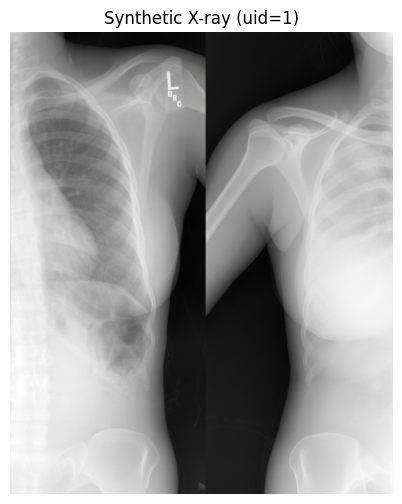

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import json

# Show metadata
with open("output/metadata.json") as f:
    meta = json.load(f)
for entry in meta:
    print(f"uid={entry['uid']}")
    if 'reference_images' in entry:
        print(f"  Reference images: {entry['reference_images']}")
    if 'image_path' in entry:
        print(f"  Generated image: {entry['image_path']}")
        img = Image.open(entry['image_path'])
        plt.figure(figsize=(6, 6))
        plt.imshow(img, cmap='gray')
        plt.title(f"Synthetic X-ray (uid={entry['uid']})")
        plt.axis('off')
        plt.show()
    elif 'error_image' in entry:
        print(f"  ❌ Error: {entry['error_image']}")
